# Mô hình ARX
Mô hình ARX dự đoán `Soil_Moisture`.

## 1. Thiết lập môi trường

Cell này nạp thư viện, cấu hình hiển thị và thêm thư mục `src` vào `sys.path` để notebook gọi lại trực tiếp các hàm đã viết trong project.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from config import ExperimentConfig, INPUT_COLS
from data.collection.step_00_data_io import MODEL_COLS, input_csv_paths
from data.collection.step_01_clean_data import clean_data_file
from preprocessing import add_features, inverse_y, split_time
from algorithm import ArxSpec, max_lag, predict_one_step, simulate_chunked, simulate_free_run

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = PROJECT_ROOT / "data"
RESULT_DIR = PROJECT_ROOT / "result"

RAW_SUMMARY_PATH = DATA_DIR / "_01_data" / "00_raw_tong_hop.csv"
CLEAN_SUMMARY_PATH = DATA_DIR / "_02_clean_data" / "00_sau_xu_ly_tong_hop.csv"
TRAIN_DATA_PATH = DATA_DIR / "mini_greenhouse_5s_data.csv"
METRICS_PATH = RESULT_DIR / "metrics.json"
MODEL_PATH = RESULT_DIR / "arx_5s_model.json"
PRED_PATH = RESULT_DIR / "test_predictions.csv"
LEADERBOARD_PATH = RESULT_DIR / "leaderboard.csv"

print("Thư mục project:", PROJECT_ROOT)
print("Thư mục data:", DATA_DIR)
print("Thư mục result:", RESULT_DIR)

Thư mục project: C:\Users\minht\OneDrive\Desktop\ARX-Model\ARX_DO_BY_SELF
Thư mục data: C:\Users\minht\OneDrive\Desktop\ARX-Model\ARX_DO_BY_SELF\data
Thư mục result: C:\Users\minht\OneDrive\Desktop\ARX-Model\ARX_DO_BY_SELF\result


## 2. Nạp dữ liệu

Nạp dữ liệu.

In [2]:
raw_df = pd.read_csv(RAW_SUMMARY_PATH, parse_dates=["Timestamp"])
clean_df = pd.read_csv(CLEAN_SUMMARY_PATH, parse_dates=["Timestamp"])
data_df = pd.read_csv(TRAIN_DATA_PATH, parse_dates=["Timestamp"])
pred_df = pd.read_csv(PRED_PATH, parse_dates=["Timestamp"])
leaderboard = pd.read_csv(LEADERBOARD_PATH)

with open(METRICS_PATH, "r", encoding="utf-8") as f:
    metrics = json.load(f)

with open(MODEL_PATH, "r", encoding="utf-8") as f:
    model_artifact = json.load(f)

summary_table = pd.DataFrame(
    [
        ["Raw tổng hợp", len(raw_df), int(raw_df.isna().sum().sum()), raw_df["Timestamp"].min(), raw_df["Timestamp"].max()],
        ["Sau xử lý", len(clean_df), int(clean_df.isna().sum().sum()), clean_df["Timestamp"].min(), clean_df["Timestamp"].max()],
        ["Data train", len(data_df), int(data_df.isna().sum().sum()), data_df["Timestamp"].min(), data_df["Timestamp"].max()],
        ["Test predictions", len(pred_df), int(pred_df.isna().sum().sum()), pred_df["Timestamp"].min(), pred_df["Timestamp"].max()],
    ],
    columns=["Tập dữ liệu", "Số dòng", "Missing", "Bắt đầu", "Kết thúc"],
)

display(summary_table)
print("Model hiện tại:", metrics["model"]["name"])
print("Khung giờ đánh giá:", metrics["model"].get("time_blocks"))

,Tập dữ liệu,Số dòng,Missing,Bắt đầu,Kết thúc
0,Raw tổng hợp,207409,315,2026-04-08 00:00:01,2026-04-19 23:59:56
1,Sau xử lý,207360,0,2026-04-08 00:00:00,2026-04-19 23:59:55
2,Data train,207360,0,2026-04-08 00:00:00,2026-04-19 23:59:55
3,Test predictions,11424,0,2026-04-19 06:08:00,2026-04-19 21:59:55


Model hiện tại: ARX_na96_nb16_nk2_alpha10
Khung giờ đánh giá: [[6.0, 22.0]]


## 3. Cấu trúc raw data theo ngày và block thu

Raw data được tổ chức theo ngày thu. Mỗi ngày gồm 9 block liên tiếp phủ đủ 00:00 đến 24:00: midnight, morning, late_morning, noon, early_afternoon, afternoon, evening, night và late_night. Cách tổ chức này thể hiện quá trình thu thập trước khi clean và ghép thành dữ liệu train.


,day,session,file,rows,missing
0,2026-04-08,01_morning,2026-04-08\01_morning_raw.csv,1440,1
1,2026-04-08,02_late_morning,2026-04-08\02_late_morning_raw.csv,1801,2
2,2026-04-08,03_noon,2026-04-08\03_noon_raw.csv,1440,8
3,2026-04-08,04_early_afternoon,2026-04-08\04_early_afternoon_raw.csv,1080,3
4,2026-04-08,05_afternoon,2026-04-08\05_afternoon_raw.csv,1442,3
...,...,...,...,...,...
91,2026-04-19,04_early_afternoon,2026-04-19\04_early_afternoon_raw.csv,1080,3
92,2026-04-19,05_afternoon,2026-04-19\05_afternoon_raw.csv,1442,0
93,2026-04-19,06_evening,2026-04-19\06_evening_raw.csv,2160,1
94,2026-04-19,07_night,2026-04-19\07_night_raw.csv,1441,2


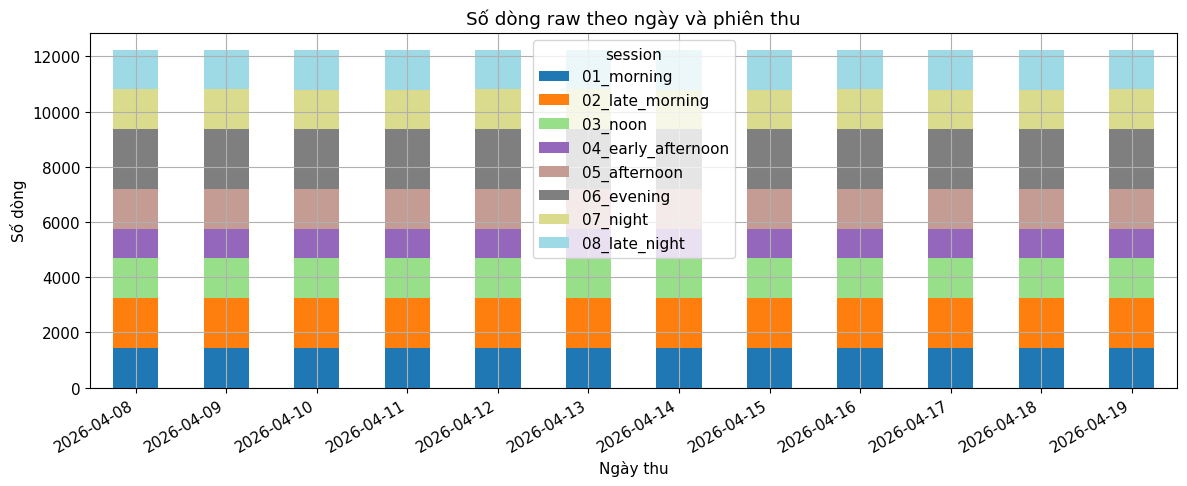

In [3]:
raw_paths = input_csv_paths(DATA_DIR / "_01_data")
raw_files = []
for path in raw_paths:
    if path.name.startswith("00_"):
        continue
    df_tmp = pd.read_csv(path)
    rel = path.relative_to(DATA_DIR / "_01_data")
    day = rel.parts[0] if len(rel.parts) > 1 else "root"
    session = path.stem.replace("_raw", "")
    raw_files.append({"day": day, "session": session, "file": str(rel), "rows": len(df_tmp), "missing": int(df_tmp.isna().sum().sum())})

raw_files_df = pd.DataFrame(raw_files).sort_values(["day", "session"])
display(raw_files_df)

rows_by_day_session = raw_files_df.pivot_table(index="day", columns="session", values="rows", aggfunc="sum").fillna(0)
ax = rows_by_day_session.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab20")
ax.set_title("Số dòng raw theo ngày và phiên thu")
ax.set_xlabel("Ngày thu")
ax.set_ylabel("Số dòng")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4. Kết quả clean data

Kiểm tra nhanh trước và sau xử lý.

In [4]:
sensor_cols = ["Temperature", "Humidity", "Light", "Soil_Moisture"]
actuator_cols = ["Drip", "Mist", "Fan"]
check_cols = list(MODEL_COLS)


def error_summary(name: str, df: pd.DataFrame) -> dict:
    duplicate_timestamp = int(df["Timestamp"].duplicated().sum())
    invalid_actuator = 0
    for col in actuator_cols:
        values = df[col].dropna().astype(float)
        invalid_actuator += int((~values.isin([0.0, 1.0])).sum())
    missing = int(df[check_cols].isna().sum().sum())
    return {
        "Dataset": name,
        "Số dòng": len(df),
        "Missing": missing,
        "Duplicate timestamp": duplicate_timestamp,
        "Actuator lỗi": invalid_actuator,
        "Tổng lỗi kiểm tra": missing + duplicate_timestamp + invalid_actuator,
        "Bắt đầu": df["Timestamp"].min(),
        "Kết thúc": df["Timestamp"].max(),
        "Số ngày": df["Timestamp"].dt.normalize().nunique(),
    }

clean_result_table = pd.DataFrame([
    error_summary("Trước clean", raw_df),
    error_summary("Sau clean", clean_df),
])
display(clean_result_table)

total_data_table = pd.DataFrame([
    error_summary("Data train cuối", data_df),
])
display(total_data_table)

,Dataset,Số dòng,Missing,Duplicate timestamp,Actuator lỗi,Tổng lỗi kiểm tra,Bắt đầu,Kết thúc,Số ngày
0,Trước clean,207409,315,49,0,364,2026-04-08 00:00:01,2026-04-19 23:59:56,12
1,Sau clean,207360,0,0,0,0,2026-04-08 00:00:00,2026-04-19 23:59:55,12


,Dataset,Số dòng,Missing,Duplicate timestamp,Actuator lỗi,Tổng lỗi kiểm tra,Bắt đầu,Kết thúc,Số ngày
0,Data train cuối,207360,0,0,0,0,2026-04-08,2026-04-19 23:59:55,12


## 5. Dữ liệu train cuối cùng

Từ dữ liệu sau xử lý, pipeline sinh ra `mini_greenhouse_5s_data.csv` gồm 12 ngày dữ liệu 5 giây. Đây là file được dùng để huấn luyện mô hình ARX.

,Số dòng,Missing,Bắt đầu,Kết thúc,Số ngày
0,207360,0,2026-04-08,2026-04-19 23:59:55,12


,Min,Mean,Max,Std
Temperature,27.800,30.180,32.700,0.970
Humidity,37.000,52.240,81.000,8.980
Light,0.000,224.120,795.700,265.640
Soil_Moisture,52.700,54.110,57.500,0.610


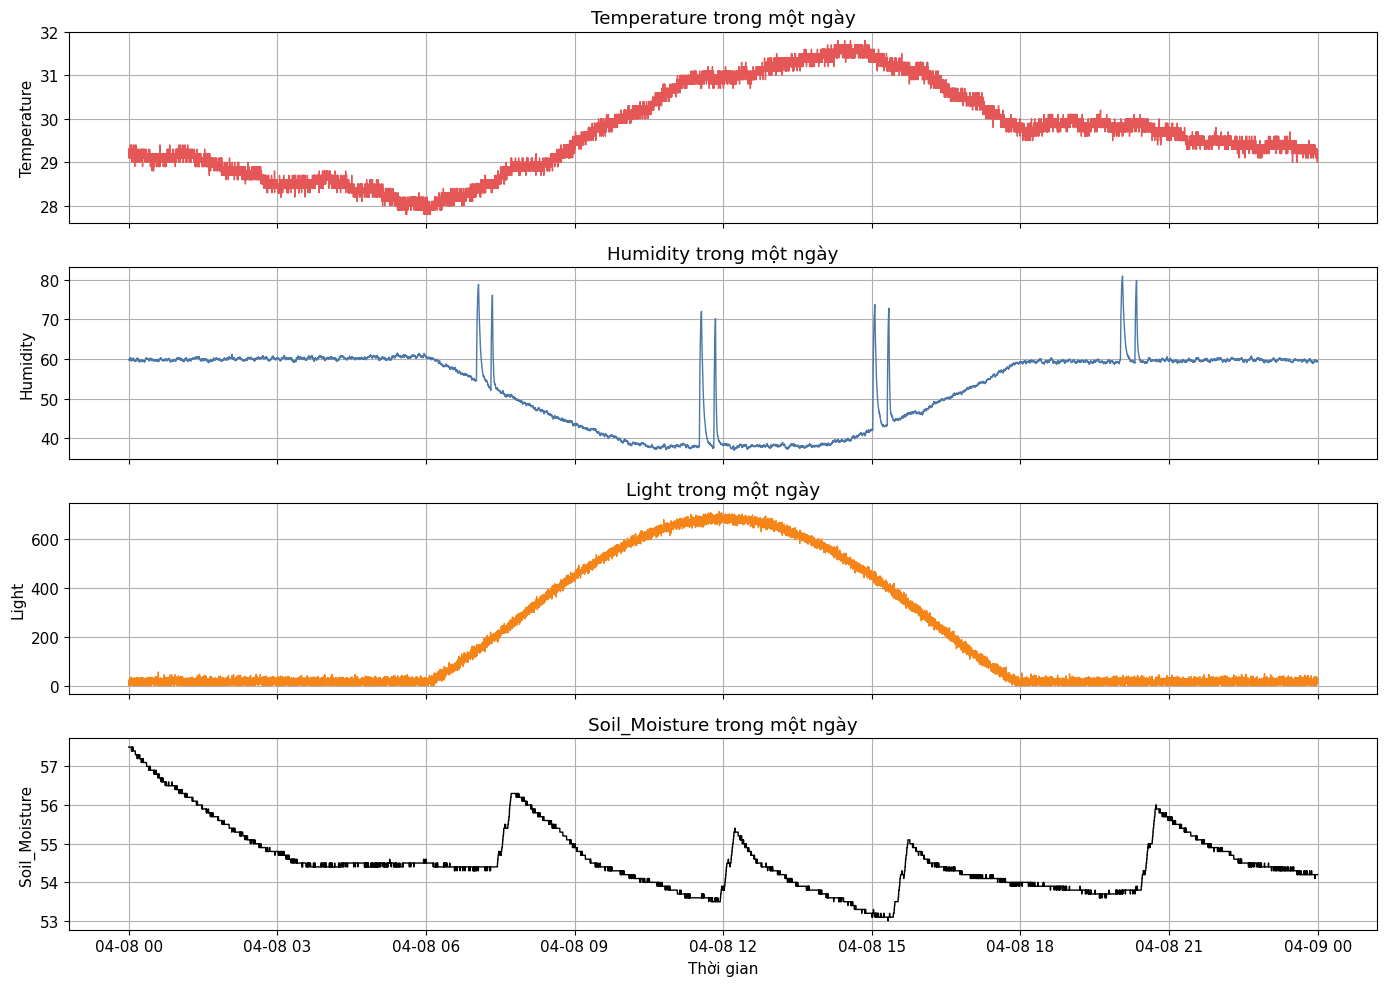

In [5]:
one_day = data_df[data_df["Timestamp"].dt.normalize() == data_df["Timestamp"].dt.normalize().iloc[0]].copy()

data_train_overview = pd.DataFrame([
    {
        "Số dòng": len(data_df),
        "Missing": int(data_df[check_cols].isna().sum().sum()),
        "Bắt đầu": data_df["Timestamp"].min(),
        "Kết thúc": data_df["Timestamp"].max(),
        "Số ngày": data_df["Timestamp"].dt.normalize().nunique(),
    }
])
display(data_train_overview)

train_data_summary = (
    data_df[sensor_cols]
    .agg(["min", "mean", "max", "std"])
    .T
    .rename(columns={"min": "Min", "mean": "Mean", "max": "Max", "std": "Std"})
)
display(train_data_summary.round(2))

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, col, color in zip(axes, sensor_cols, ["#E45756", "#4C78A8", "#F58518", "black"]):
    ax.plot(one_day["Timestamp"], one_day[col], color=color, linewidth=1.0)
    ax.set_ylabel(col)
    ax.set_title(f"{col} trong một ngày")
axes[-1].set_xlabel("Thời gian")
plt.tight_layout()
plt.show()

## 6. Actuator, setpoint và Soil_Moisture

Biểu đồ này kiểm tra dữ liệu có chứa tín hiệu điều khiển. Nếu `Drip`, `Mist`, `Fan` không thay đổi, mô hình ARX khó học đáp ứng động học.

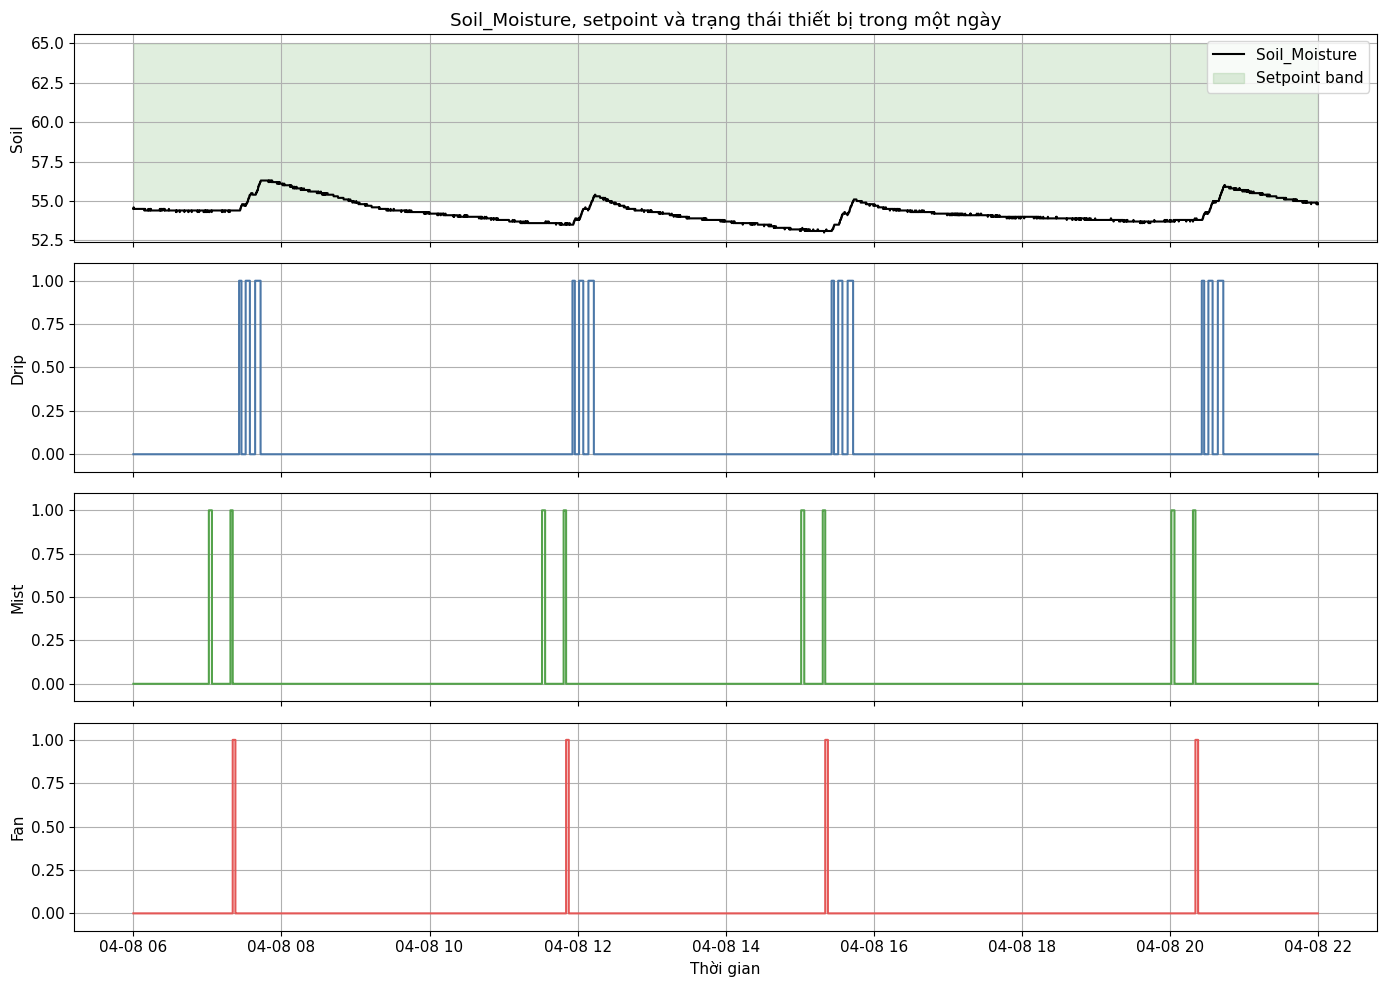

In [6]:
plot_cfg = ExperimentConfig()
example_day = data_df[data_df["Timestamp"].dt.normalize() == data_df["Timestamp"].dt.normalize().iloc[0]].copy()
window = example_day[(example_day["Timestamp"].dt.hour >= 6) & (example_day["Timestamp"].dt.hour < 22)].copy()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(window["Timestamp"], window["Soil_Moisture"], color="black", label="Soil_Moisture")
axes[0].fill_between(window["Timestamp"], plot_cfg.soil_low_sp, plot_cfg.soil_high_sp, alpha=0.18, color="#54A24B", label="Setpoint band")
axes[0].set_title("Soil_Moisture, setpoint và trạng thái thiết bị trong một ngày")
axes[0].legend(loc="upper right")
axes[0].set_ylabel("Soil")
for ax, col, color in zip(axes[1:], ["Drip", "Mist", "Fan"], ["#4C78A8", "#54A24B", "#E45756"]):
    ax.step(window["Timestamp"], window[col], where="post", color=color)
    ax.set_ylabel(col)
    ax.set_ylim(-0.1, 1.1)
axes[-1].set_xlabel("Thời gian")
plt.tight_layout()
plt.show()

## 7. Feature engineering

Các feature phụ gồm `Light_log`, các feature tương tác môi trường, `Air_Dryness`, `Temp_x_Air_Dryness`, và feature chu kỳ thời gian. Các feature này được sinh bằng hàm `add_features()` trong `src`.

In [7]:
featured_df = add_features(data_df)
cfg = ExperimentConfig()
train_df, val_df, test_df = split_time(featured_df, cfg)

feature_table = pd.DataFrame({
    "Feature": list(INPUT_COLS),
    "Nhóm": ["Gốc" if c in ["Temperature", "Humidity", "Light", "Drip", "Mist", "Fan"] else "Phụ" for c in INPUT_COLS],
    "Có trong raw": [c in MODEL_COLS for c in INPUT_COLS],
})
display(feature_table)

,Feature,Nhóm,Có trong raw
0,Temperature,Gốc,True
1,Humidity,Gốc,True
2,Light,Gốc,True
3,Drip,Gốc,True
4,Mist,Gốc,True
5,Fan,Gốc,True
6,Light_log,Phụ,False
7,Temp_x_Humidity,Phụ,False
8,Temp_x_Light,Phụ,False
9,Humidity_x_Light,Phụ,False


## 8. Chia train, validation và test

Dữ liệu được chia theo ngày. Train gồm các ngày trước, validation là ngày kế cuối, test là ngày cuối. Mỗi ngày chỉ lấy khung giờ `6:00-22:00` nên validation và test có số mẫu bằng nhau.

,Split,Số ngày,Số dòng,Dòng/ngày,Tỷ lệ (%),Bắt đầu,Kết thúc
0,Train,10,115200,"11,520.000",83.330,2026-04-08 06:00:00,2026-04-17 21:59:55
1,Validation,1,11520,"11,520.000",8.330,2026-04-18 06:00:00,2026-04-18 21:59:55
2,Test,1,11520,"11,520.000",8.330,2026-04-19 06:00:00,2026-04-19 21:59:55


Khung giờ dùng: [[6.0, 22.0]]
Mỗi ngày 6:00-22:00 có 11520 mẫu với chu kỳ 5 giây.


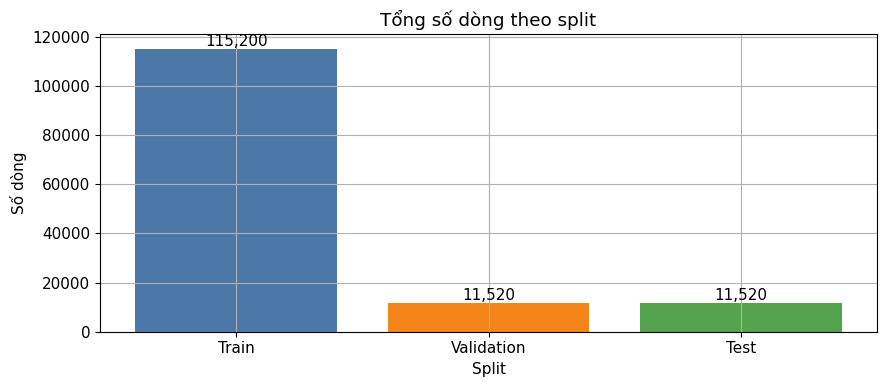

In [8]:
def split_summary(name: str, df: pd.DataFrame) -> dict:
    dates = df["Timestamp"].dt.normalize()
    return {
        "Split": name,
        "Số ngày": dates.nunique(),
        "Số dòng": len(df),
        "Dòng/ngày": len(df) / max(dates.nunique(), 1),
        "Tỷ lệ (%)": 100 * len(df) / (len(train_df) + len(val_df) + len(test_df)),
        "Bắt đầu": df["Timestamp"].min(),
        "Kết thúc": df["Timestamp"].max(),
    }

split_table = pd.DataFrame([
    split_summary("Train", train_df),
    split_summary("Validation", val_df),
    split_summary("Test", test_df),
])
display(split_table.round({"Dòng/ngày": 0, "Tỷ lệ (%)": 2}))

print("Khung giờ dùng:", metrics["model"].get("time_blocks"))
print("Mỗi ngày 6:00-22:00 có", int(16 * 3600 / cfg.sampling_seconds), "mẫu với chu kỳ 5 giây.")

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#4C78A8", "#F58518", "#54A24B"]
ax.bar(split_table["Split"], split_table["Số dòng"], color=colors)
ax.set_title("Tổng số dòng theo split")
ax.set_xlabel("Split")
ax.set_ylabel("Số dòng")
for i, row in split_table.iterrows():
    ax.text(i, row["Số dòng"], f'{int(row["Số dòng"]):,}', ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 9. Thuật toán ARX tự xây dựng

Thuật toán ARX được tự cài đặt trong `src/algorithm/arx.py`, không gọi thư viện ARX, model Ridge có sẵn hay `np.linalg.lstsq`. Code tự tạo ma trận hồi quy, tự giải hệ để tìm `theta`, rồi dùng chính công thức ARX để dự đoán.

Các bước chính:

```text
1. Tạo ma trận Phi từ y quá khứ và input quá khứ.
2. Tạo vector Y là Soil_Moisture tại thời điểm cần dự đoán.
3. Fit hệ số theta bằng nghiệm tuyến tính:
   theta = (Phi^T Phi + alpha I)^(-1) Phi^T Y
4. Dự đoán y_hat bằng công thức ARX với theta đã fit.
```

In [9]:
algorithm_table = pd.DataFrame(
    [
        ["build_arx_matrix()", "Tự tạo ma trận Phi và vector Y từ dữ liệu quá khứ"],
        ["fit_arx()", "Tự fit theta bằng normal equation và np.linalg.solve, không dùng lstsq/sklearn/statsmodels"],
        ["predict_at()", "Tự tính y_hat tại một thời điểm từ theta và các lag"],
        ["predict_one_step()", "Dự đoán 1-step bằng y quá khứ thật"],
        ["simulate_free_run()", "Mô phỏng tự do, dùng lại y_hat làm quá khứ"],
        ["simulate_chunked()", "Mô phỏng theo từng đoạn 5 phút/20 phút"],
    ],
    columns=["Hàm tự viết", "Vai trò"],
)
display(algorithm_table)

model = metrics["model"]
spec = ArxSpec(**model_artifact["spec"])
input_cols = list(model_artifact["input_cols"])

theta_formula_table = pd.DataFrame(
    [
        ["na", spec.na, "Số bậc hồi quy của Soil_Moisture"],
        ["nb", spec.nb, "Số bậc của mỗi input"],
        ["nk", spec.nk, "Độ trễ input"],
        ["alpha", spec.alpha, "Hệ số regularization tự đưa vào khi giải theta"],
        ["Số hệ số theta", len(model_artifact["theta"]), "Tổng số hệ số tự ước lượng"],
    ],
    columns=["Tham số", "Giá trị", "Ý nghĩa"],
)
display(theta_formula_table)

,Hàm tự viết,Vai trò
0,build_arx_matrix(),Tự tạo ma trận Phi và vector Y từ dữ liệu quá khứ
1,fit_arx(),Tự fit theta bằng normal equation và np.linalg...
2,predict_at(),Tự tính y_hat tại một thời điểm từ theta và cá...
3,predict_one_step(),Dự đoán 1-step bằng y quá khứ thật
4,simulate_free_run(),"Mô phỏng tự do, dùng lại y_hat làm quá khứ"
5,simulate_chunked(),Mô phỏng theo từng đoạn 5 phút/20 phút


,Tham số,Giá trị,Ý nghĩa
0,na,96.000,Số bậc hồi quy của Soil_Moisture
1,nb,16.000,Số bậc của mỗi input
2,nk,2.000,Độ trễ input
3,alpha,10.000,Hệ số regularization tự đưa vào khi giải theta
4,Số hệ số theta,353.000,Tổng số hệ số tự ước lượng


## 10. Chọn model bằng leaderboard

Các ứng viên ARX được fit trên train và chọn theo `Validation FIT free-run`. Đây là tiêu chí khó hơn 1-step vì mô hình phải tự dùng dự đoán của chính nó trong quá trình mô phỏng.

,model,na,nb,nk,alpha,output_memory_seconds,input_delay_seconds,input_memory_seconds,n_input_cols,n_params,val_FIT_1step,val_FIT_free_run,val_RMSE_free_run
0,ARX_na96_nb16_nk2_alpha10,96,16,2,10.000,480,10,80,16,353,96.099,82.192,0.123
1,ARX_na144_nb16_nk2_alpha10,144,16,2,10.000,720,10,80,16,401,96.099,82.160,0.123
2,ARX_na144_nb12_nk4_alpha10,144,12,4,10.000,720,20,60,16,337,96.091,79.666,0.140
3,ARX_na72_nb12_nk4_alpha10,72,12,4,10.000,360,20,60,16,265,96.092,79.661,0.140
4,ARX_na96_nb12_nk4_alpha10,96,12,4,10.000,480,20,60,16,289,96.092,79.654,0.140
5,ARX_na144_nb16_nk4_alpha100,144,16,4,100.000,720,20,80,16,401,95.979,79.463,0.142
6,ARX_na72_nb8_nk4_alpha10,72,8,4,10.000,360,20,40,16,201,96.079,78.261,0.150


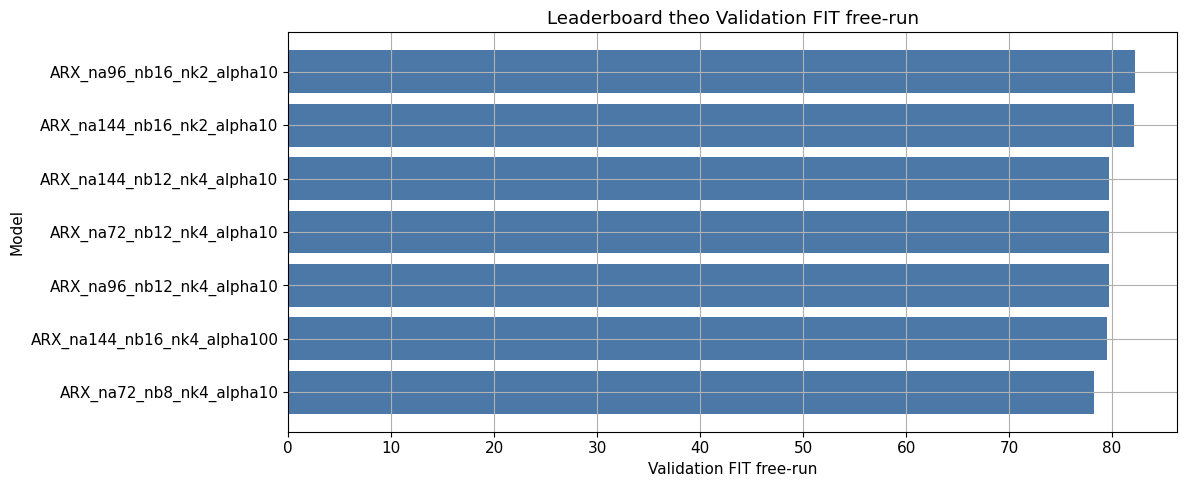

In [10]:
leader_sorted = leaderboard.sort_values("val_FIT_free_run", ascending=False)
display(leader_sorted.round(3))

fig, ax = plt.subplots(figsize=(12, 5))
plot_df = leader_sorted.sort_values("val_FIT_free_run", ascending=True)
ax.barh(plot_df["model"], plot_df["val_FIT_free_run"], color="#4C78A8")
ax.set_title("Leaderboard theo Validation FIT free-run")
ax.set_xlabel("Validation FIT free-run")
ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

## 11. Phân tích hệ số ARX

Phần này nhóm hệ số theo output quá khứ và từng input. Mục đích là kiểm tra mô hình có đang dùng thông tin hợp lý hay không.

,Nhóm,Tổng |hệ số|,Max |hệ số|
0,Soil_Moisture lags,1.480,0.815
13,Hour_sin,0.236,0.112
14,Hour_cos,0.172,0.082
15,Day_sin,0.099,0.031
12,Temp_x_Air_Dryness,0.070,0.009
16,Day_cos,0.062,0.009
9,Temp_x_Light,0.062,0.010
7,Light_log,0.054,0.008
3,Light,0.054,0.012
10,Humidity_x_Light,0.043,0.008


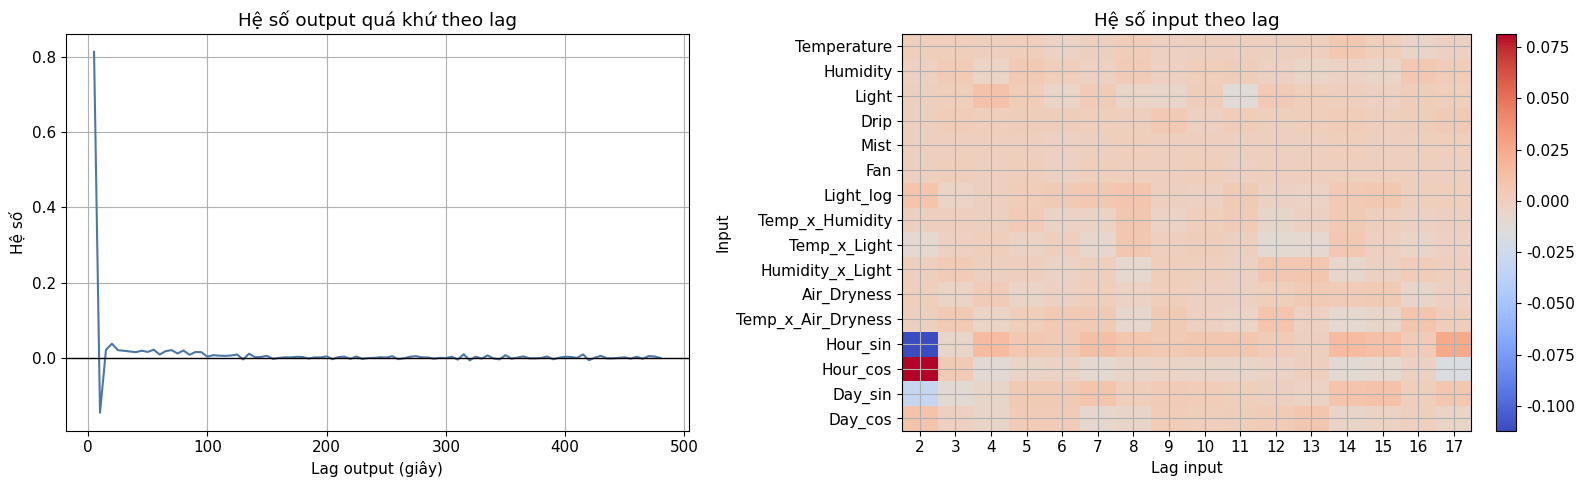

In [11]:
theta = np.array(model_artifact["theta"], dtype=float)
na, nb = spec.na, spec.nb
input_cols = list(model_artifact["input_cols"])

idx = 0
coef_y = theta[idx : idx + na]
idx += na
coef_groups = [{"Nhóm": "Soil_Moisture lags", "Tổng |hệ số|": np.abs(coef_y).sum(), "Max |hệ số|": np.abs(coef_y).max()}]
input_coef_matrix = []
for col in input_cols:
    block = theta[idx : idx + nb]
    idx += nb
    input_coef_matrix.append(block)
    coef_groups.append({"Nhóm": col, "Tổng |hệ số|": np.abs(block).sum(), "Max |hệ số|": np.abs(block).max()})
coef_group_df = pd.DataFrame(coef_groups).sort_values("Tổng |hệ số|", ascending=False)
display(coef_group_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(np.arange(1, na + 1) * cfg.sampling_seconds, coef_y, color="#4C78A8")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Hệ số output quá khứ theo lag")
axes[0].set_xlabel("Lag output (giây)")
axes[0].set_ylabel("Hệ số")

mat = np.vstack(input_coef_matrix)
im = axes[1].imshow(mat, aspect="auto", cmap="coolwarm")
axes[1].set_title("Hệ số input theo lag")
axes[1].set_xlabel("Lag input")
axes[1].set_ylabel("Input")
axes[1].set_yticks(np.arange(len(input_cols)))
axes[1].set_yticklabels(input_cols)
axes[1].set_xticks(np.arange(nb))
axes[1].set_xticklabels([str(spec.nk + i) for i in range(nb)])
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 12. Metrics tổng hợp

Các metric chính:

- `FIT`: độ khớp, càng cao càng tốt.
- `RMSE`: sai số căn phương trung bình, càng thấp càng tốt.

Bốn chế độ dự đoán: `1-step`, `5min chunked`, `20min chunked`, `free-run`.

In [12]:
def metric_table(metric_name: str) -> pd.DataFrame:
    rows = []
    for key, name in [("train", "Train"), ("validation", "Validation"), ("test", "Test")]:
        item = metrics[key]
        rows.append(
            {
                "Split": name,
                "1-step": item["metrics_1step"][metric_name],
                "5min chunked": item["metrics_5min_chunked"][metric_name],
                "20min chunked": item["metrics_20min_chunked"][metric_name],
                "Free-run": item["metrics_free_run"][metric_name],
            }
        )
    return pd.DataFrame(rows)

fit_table = metric_table("FIT")
rmse_table = metric_table("RMSE")
display(Markdown("### FIT"))
display(fit_table.round(3))
display(Markdown("### RMSE"))
display(rmse_table.round(4))


### FIT

,Split,1-step,5min chunked,20min chunked,Free-run
0,Train,95.870,92.881,90.572,80.246
1,Validation,96.099,93.426,91.154,82.192
2,Test,95.967,93.378,91.497,81.418


### RMSE

,Split,1-step,5min chunked,20min chunked,Free-run
0,Train,0.028,0.048,0.063,0.133
1,Validation,0.027,0.045,0.061,0.123
2,Test,0.026,0.043,0.055,0.121


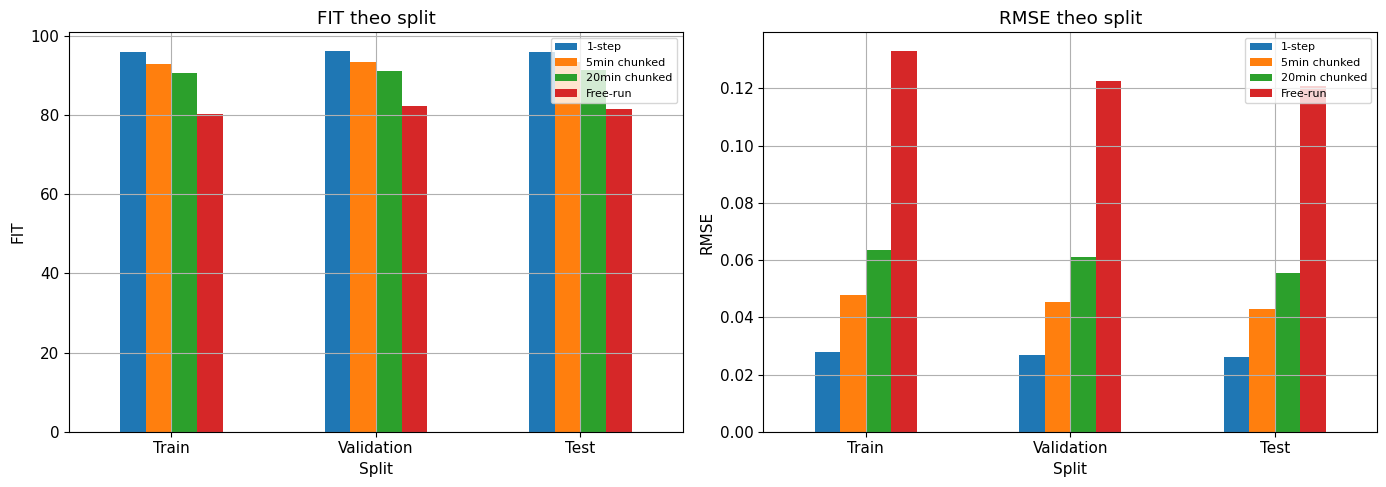

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fit_table.set_index("Split").plot(kind="bar", ax=axes[0])
axes[0].set_title("FIT theo split")
axes[0].set_ylabel("FIT")
axes[0].tick_params(axis="x", rotation=0)

rmse_table.set_index("Split").plot(kind="bar", ax=axes[1])
axes[1].set_title("RMSE theo split")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=0)

for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 13. Tái tạo dự đoán bằng hàm trong `src`

Cell này tái tạo dự đoán từ `arx_5s_model.json` bằng chính các hàm `predict_one_step`, `simulate_chunked` và `simulate_free_run`. Đây là bước kiểm tra notebook thật sự gọi lại thuật toán của project.

In [14]:
stats = {col: (item["mean"], item["std"]) for col, item in model_artifact["scale"].items()}
clip = tuple(model_artifact["clip_scaled"])

test_z = test_df.copy()
for col, (mean, std) in stats.items():
    test_z[col] = (test_z[col].astype(float) - mean) / std

y_1_z, y_true_z = predict_one_step(test_z, theta, spec, tuple(input_cols), clip)
y_5_z, _ = simulate_chunked(test_z, theta, spec, tuple(input_cols), clip, cfg.n_step_5min)
y_20_z, _ = simulate_chunked(test_z, theta, spec, tuple(input_cols), clip, cfg.n_step_control)
y_free_z, _ = simulate_free_run(test_z, theta, spec, tuple(input_cols), clip)

recomputed = pd.DataFrame(
    {
        "y_true": inverse_y(y_true_z, stats),
        "y_pred_1step": inverse_y(y_1_z, stats),
        "y_pred_5min_chunked": inverse_y(y_5_z, stats),
        "y_pred_20min_chunked": inverse_y(y_20_z, stats),
        "y_pred_free_run": inverse_y(y_free_z, stats),
    }
)

comparison = {col: float(np.max(np.abs(recomputed[col].to_numpy() - pred_df[col].to_numpy()))) for col in recomputed.columns}
display(pd.DataFrame.from_dict(comparison, orient="index", columns=["Max sai khác so với file lưu"]))

,Max sai khác so với file lưu
y_true,0.000
y_pred_1step,0.000
y_pred_5min_chunked,0.000
y_pred_20min_chunked,0.000
y_pred_free_run,0.000


## 14. Dự đoán trên tập test

Biểu đồ dưới đây so sánh giá trị thật với bốn chế độ dự đoán trên toàn bộ tập test. Free-run là chế độ khó nhất vì lỗi có thể tích lũy theo thời gian.

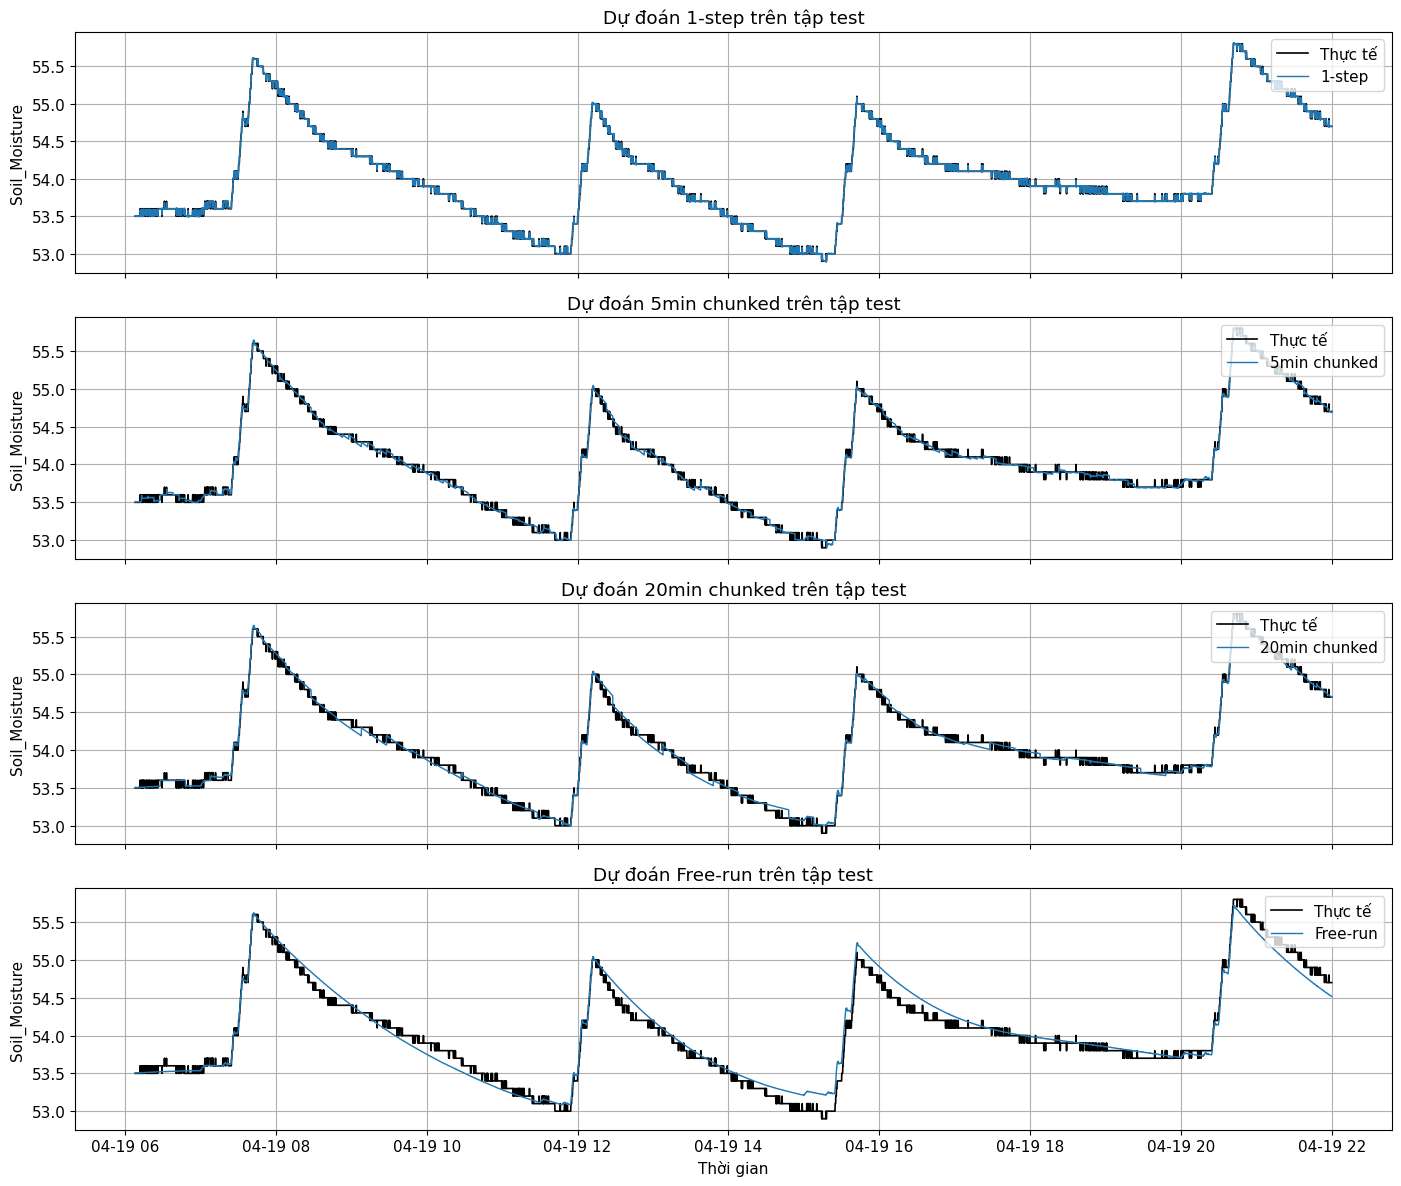

In [15]:
pred_cols = [
    ("y_pred_1step", "1-step"),
    ("y_pred_5min_chunked", "5min chunked"),
    ("y_pred_20min_chunked", "20min chunked"),
    ("y_pred_free_run", "Free-run"),
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, (col, label) in zip(axes, pred_cols):
    ax.plot(pred_df["Timestamp"], pred_df["y_true"], label="Thực tế", color="black", linewidth=1.2)
    ax.plot(pred_df["Timestamp"], pred_df[col], label=label, linewidth=1.0)
    ax.set_title(f"Dự đoán {label} trên tập test")
    ax.set_ylabel("Soil_Moisture")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Thời gian")
plt.tight_layout()
plt.show()

## 15. Phân tích residual

Residual được tính bằng `y_pred - y_true`. Residual có trung bình gần 0 cho thấy mô hình không bị lệch hệ thống lớn.

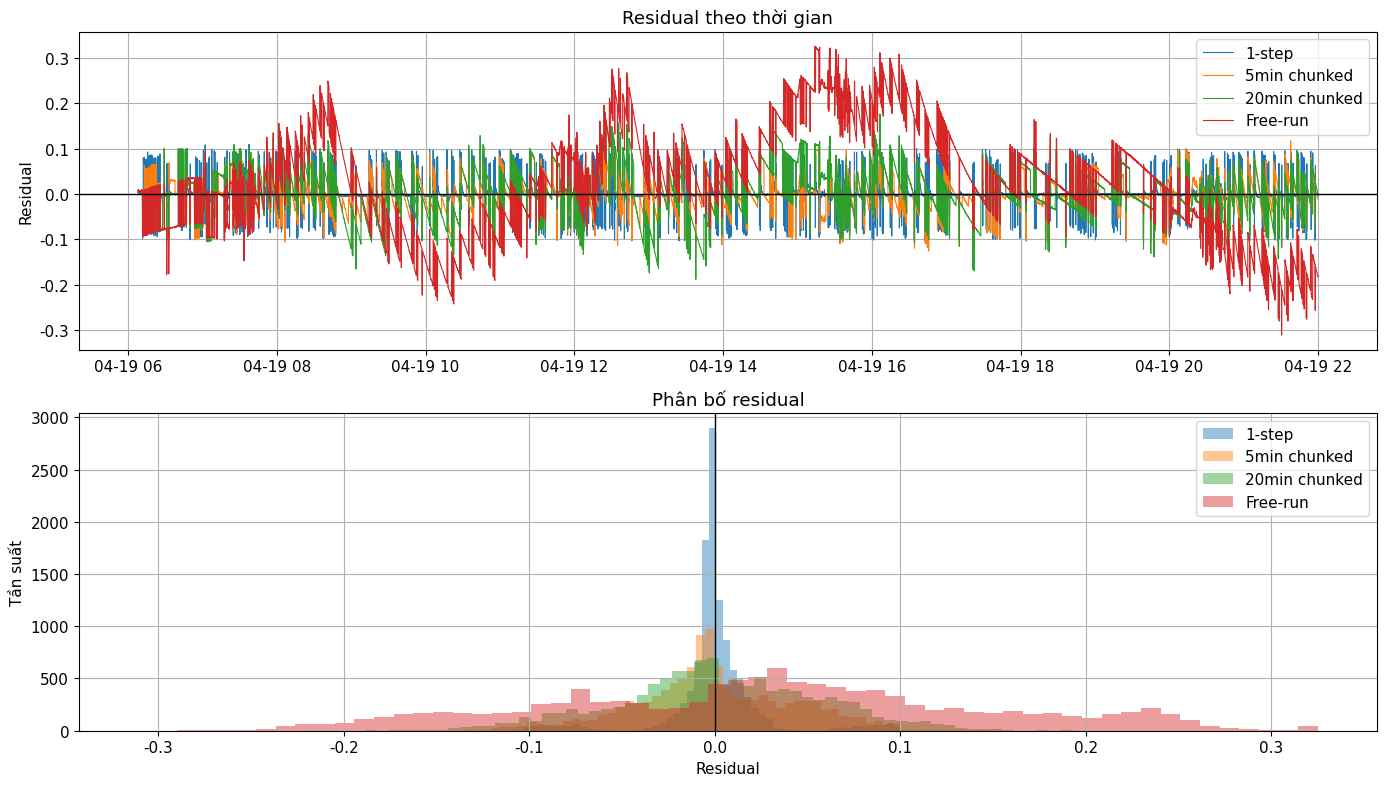

,mean,std,min,max
1-step,0.000,0.026,-0.115,0.116
5min chunked,-0.000,0.043,-0.140,0.148
20min chunked,0.002,0.055,-0.188,0.193
Free-run,0.027,0.118,-0.311,0.325


In [16]:
residual_df = pd.DataFrame({"Timestamp": pred_df["Timestamp"]})
for col, label in pred_cols:
    residual_df[label] = pred_df[col] - pred_df["y_true"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for label in [label for _, label in pred_cols]:
    axes[0].plot(residual_df["Timestamp"], residual_df[label], linewidth=0.8, label=label)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residual theo thời gian")
axes[0].set_ylabel("Residual")
axes[0].legend()

for label in [label for _, label in pred_cols]:
    axes[1].hist(residual_df[label], bins=60, alpha=0.45, label=label)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Phân bố residual")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Tần suất")
axes[1].legend()
plt.tight_layout()
plt.show()

display(residual_df.drop(columns=["Timestamp"]).agg(["mean", "std", "min", "max"]).T.round(4))